In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Perform Appropriate Scaling and Validation Data split

In [5]:
map_forecast_path = "data/map-forecast"
df_train_full = pd.read_csv(f"{map_forecast_path}/dataframe/df_map_train.csv")
df_test = pd.read_csv(f"{map_forecast_path}/dataframe/df_map_test.csv")
# get list of unique stay_id
train_ids = list(set(df_train_full['stay_id'].values))
test_ids = list(set(df_test['stay_id'].values))
print(test_ids)
df_train_full

[np.int64(34617352), np.int64(39804682), np.int64(37057036), np.int64(37323533), np.int64(31959184), np.int64(35024147), np.int64(30913302), np.int64(36091287), np.int64(30585761), np.int64(31338022), np.int64(34592300), np.int64(35436337), np.int64(32391858), np.int64(35544374), np.int64(32283063), np.int64(35727289), np.int64(38197705), np.int64(32155744), np.int64(34531557), np.int64(32453351), np.int64(31316840), np.int64(36107367), np.int64(34170353), np.int64(31205490), np.int64(30849778), np.int64(35044342)]


,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,37067082,2157-11-20 19:00:00,104.0,55.0,1.0,86.0,18.0,98.5,0.0,6.0,35.131745,0.0
1,37067082,2157-11-20 20:00:00,95.0,55.0,1.0,91.0,24.0,98.5,0.0,6.0,75.282311,0.0
2,37067082,2157-11-20 21:00:00,103.0,55.0,1.0,95.0,25.0,98.5,0.0,6.0,75.282311,0.0
3,37067082,2157-11-20 22:00:00,93.0,55.0,1.0,102.0,27.0,99.1,0.0,6.0,75.282311,0.0
4,37067082,2157-11-20 23:00:00,88.0,55.0,1.0,106.0,20.0,99.1,0.0,6.0,75.282311,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9312,36893762,2134-09-08 17:00:00,99.0,67.0,1.0,99.0,21.0,98.6,0.0,6.0,0.000000,0.0
9313,36893762,2134-09-08 18:00:00,101.0,67.0,1.0,103.0,20.0,98.6,0.0,6.0,0.000000,0.0
9314,36893762,2134-09-08 19:00:00,92.0,67.0,1.0,94.0,17.0,98.6,0.0,6.0,0.000000,0.0
9315,36893762,2134-09-08 20:00:00,108.0,67.0,1.0,97.0,17.0,98.6,0.0,6.0,0.000000,0.0


In [ ]:
#### Obtain train-val split for validation set
# 1. Get unique Stay IDs
unique_stays = df_train_full['stay_id'].unique()

# 2. Randomly shuffle and split
np.random.seed(42) # Use seed for reproducibility
np.random.shuffle(unique_stays)

train_size = int(len(unique_stays) * 0.85)
train_ids = unique_stays[:train_size]
val_ids = unique_stays[train_size:]

# 3. Create the dataframes
df_train = df_train_full[df_train_full['stay_id'].isin(train_ids)]
df_val = df_train_full[df_train_full['stay_id'].isin(val_ids)]

df_val

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
27,34807493,2156-04-30 22:00:00,112.0,81.0,1.0,107.0,25.5,98.4,5.0,5.0,5.0,0.0
28,34807493,2156-04-30 23:00:00,51.0,81.0,1.0,105.0,22.0,98.4,5.0,5.0,5.0,0.0
29,34807493,2156-05-01 00:00:00,59.0,81.0,1.0,98.0,29.0,98.4,5.0,5.0,5.0,0.0
30,34807493,2156-05-01 01:00:00,63.0,81.0,1.0,87.0,23.0,98.4,5.0,5.0,5.0,0.0
31,34807493,2156-05-01 02:00:00,59.0,81.0,1.0,86.0,25.0,98.4,5.0,5.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9284,39142259,2115-12-30 05:00:00,75.0,57.0,1.0,103.0,27.0,98.7,0.0,6.0,0.0,0.0
9285,39142259,2115-12-30 06:00:00,79.0,57.0,1.0,102.0,21.0,98.7,0.0,6.0,0.0,0.0
9286,39142259,2115-12-30 07:00:00,86.0,57.0,1.0,99.0,28.0,98.7,0.0,6.0,0.0,0.0
9287,39142259,2115-12-30 08:00:00,80.0,57.0,1.0,108.0,16.0,99.4,0.0,6.0,0.0,0.0


### Scale the features

Each features are scaled differently, standard features like MAP, Heart Rate are generally normally distributed, making it suitable for standard scaling. Some parameter like the drug based parameter contains an actual meaning when no drug is distributed (0), so making this value negative is awkward if we do standard scaing and make it more difficult. Gender and GCS are binary and integers respectively, so no scaling needed

In [ ]:
# 1. Create copies so we don't overwrite the raw data
df_train_scaled = df_train.copy()
df_val_scaled = df_val.copy()
df_test_scaled = df_test.copy()

# 2. Define groups
vitals = ['MAP', 'Heart Rate', 'Respiratory Rate', 'Temperature Fahrenheit', 'age']
drugs = ['Norepinephrine', 'NaCl 0.9%', 'PEEP set']

# 3. Scale Vitals (Standard)
scaler_std = StandardScaler()
df_train_scaled[vitals] = scaler_std.fit_transform(df_train_scaled[vitals])
df_val_scaled[vitals] = scaler_std.transform(df_val_scaled[vitals])
df_test_scaled[vitals] = scaler_std.transform(df_test_scaled[vitals])

# 4. Scale Drugs (MinMax)
scaler_mm = MinMaxScaler()
df_train_scaled[drugs] = scaler_mm.fit_transform(df_train_scaled[drugs])
df_val_scaled[drugs] = scaler_mm.transform(df_val_scaled[drugs])
df_test_scaled[drugs] = scaler_mm.transform(df_test_scaled[drugs])


### Convert data structure into a forecasting window and prepare data loader

In [ ]:
# Create forecasting window where we have the 12 timestamp as training data 
def create_forecasting_windows(df, features, target_col, lookback=12, horizon=6):
    X, y = [], []
    
    # Group by stay_id to ensure we don't bleed data between different patients
    for sid, group in df.groupby('stay_id'):
        # Sort by time just in case
        group = group.sort_values('charttime')
        values = group[features].values
        targets = group[target_col].values
        
        # Sliding window logic
        # We stop before we run out of 'horizon' data
        for i in range(len(group) - lookback - horizon + 1):
            # X: The 12-hour window of all features
            X.append(values[i : i + lookback])
            
            # y: The next 6 values of MAP
            y.append(targets[i + lookback : i + lookback + horizon])
            
    return np.array(X), np.array(y)

In [26]:
def prepare_lstm_data(df_train, df_val, df_test, feature_list, target_col='MAP', batch_size=16):
    """Creates windows and returns DataLoaders for a specific set of features."""
    # Create windows using your existing create_forecasting_windows logic
    X_train, y_train = create_forecasting_windows(df_train, feature_list, target_col)
    X_val, y_val     = create_forecasting_windows(df_val, feature_list, target_col)
    X_test, y_test   = create_forecasting_windows(df_test, feature_list, target_col)

    # Convert to Tensors
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

    # Create Loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    # We return X_test so we can use it for the 'History' plots later
    return train_loader, val_loader, test_loader, X_test

### Model Definition

In [27]:
class MultiHorizonLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout_prob, horizon=6):
        super(MultiHorizonLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout_prob)
        # Output layer maps the last hidden state to all 6 hours of the forecast
        self.fc = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        # Use the hidden state of the LAST time step (index -1)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

### Hyperparameter Tuning with Bayesian Optimisation

In [28]:
def create_objective(input_dim, loader_train, loader_val):
    def objective(trial):
        # Hyperparameter Search Space
        h_dim = trial.suggest_int("hidden_dim", 16, 128, step=16) # Tightened for N=136
        n_layers = trial.suggest_int("num_layers", 1, 5) 
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        drop = trial.suggest_float("dropout", 0.1, 0.5)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Now input_dim is dynamic!
        model = MultiHorizonLSTM(input_dim, h_dim, n_layers, drop).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.L1Loss() 

        for epoch in range(30):
            model.train()
            for bx, by in loader_train:
                optimizer.zero_grad()
                loss = criterion(model(bx.to(device)), by.to(device))
                loss.backward()
                optimizer.step()
            
            model.eval()
            val_mae = 0
            with torch.no_grad():
                for bx, by in loader_val:
                    val_mae += criterion(model(bx.to(device)), by.to(device)).item()
            
            score = val_mae / len(loader_val)
            trial.report(score, epoch)
            if trial.should_prune(): raise optuna.exceptions.TrialPruned()

        return score
    return objective

### Training and Evaluation of the LSTM

In [29]:
def train_final_lstm(train_loader, val_loader, params, input_dim, model_name='best_lstm.pth'):
    """Retrains the model using optimized parameters and saves the best state."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = MultiHorizonLSTM(
        input_dim=input_dim, 
        hidden_dim=params['hidden_dim'], 
        num_layers=params['num_layers'], 
        dropout_prob=params['dropout'], 
        horizon=6
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.L1Loss()
    best_val_loss = float('inf')

    for epoch in range(100):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx.to(device)), by.to(device))
            loss.backward()
            optimizer.step()
        
        # Validation Check
        model.eval()
        curr_val = 0
        with torch.no_grad():
            for bx, by in val_loader:
                curr_val += criterion(model(bx.to(device)), by.to(device)).item()
        
        avg_val = curr_val / len(val_loader)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), model_name)
            
    # Load the best weights before returning
    model.load_state_dict(torch.load(model_name))
    return model

In [30]:
def evaluate_lstm(model, test_loader, scaler_std):
    """Generates predictions and calculates MAE in mmHg."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds, all_actuals = [], []

    with torch.no_grad():
        for bx, by in test_loader:
            all_preds.append(model(bx.to(device)).cpu().numpy())
            all_actuals.append(by.numpy())

    preds_scaled = np.vstack(all_preds)
    actuals_scaled = np.vstack(all_actuals)

    # Inverse scaling (Manual MAP recovery)
    map_std, map_mean = scaler_std.scale_[0], scaler_std.mean_[0]
    preds_mmhg = (preds_scaled * map_std) + map_mean
    actuals_mmhg = (actuals_scaled * map_std) + map_mean

    # Calculate metrics
    mae_1 = np.mean(np.abs(preds_mmhg[:,0] - actuals_mmhg[:,0]))
    mae_3 = np.mean(np.abs(preds_mmhg[:,2] - actuals_mmhg[:,2]))
    mae_6 = np.mean(np.abs(preds_mmhg[:,5] - actuals_mmhg[:,5]))
    
    print(f"Results: t+1: {mae_1:.2f} | t+3: {mae_3:.2f} | t+6: {mae_6:.2f}")
    return preds_mmhg, actuals_mmhg

In [87]:
def evaluate_lstm(model, train_loader, test_loader, scaler_std):
    """
    Evaluates LSTM on both train and test sets to detect over/underfitting.
    Returns metrics and predictions.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    map_std, map_mean = scaler_std.scale_[0], scaler_std.mean_[0]
    results = {}

    def get_metrics(loader):
        all_preds, all_actuals = [], []
        with torch.no_grad():
            for bx, by in loader:
                all_preds.append(model(bx.to(device)).cpu().numpy())
                all_actuals.append(by.numpy())
        
        preds_scaled = np.vstack(all_preds)
        actuals_scaled = np.vstack(all_actuals)
        
        # Recover mmHg
        preds_mmhg = (preds_scaled * map_std) + map_mean
        actuals_mmhg = (actuals_scaled * map_std) + map_mean
        
        # Calculate MAE per horizon
        maes = {
            "mae_1": np.mean(np.abs(preds_mmhg[:,0] - actuals_mmhg[:,0])),
            "mae_3": np.mean(np.abs(preds_mmhg[:,2] - actuals_mmhg[:,2])),
            "mae_6": np.mean(np.abs(preds_mmhg[:,5] - actuals_mmhg[:,5]))
        }
        return maes, preds_mmhg, actuals_mmhg

    # 1. Evaluate Train
    train_metrics, _, _ = get_metrics(train_loader)
    
    # 2. Evaluate Test
    test_metrics, test_preds, test_actuals = get_metrics(test_loader)

    # Print Comparison
    print(f"{'Horizon':<10} | {'Train MAE':<10} | {'Test MAE':<10} | {'Gap':<10}")
    print("-" * 45)
    for h in [1, 3, 6]:
        tr = train_metrics[f"mae_{h}"]
        ts = test_metrics[f"mae_{h}"]
        gap = ts - tr
        print(f"t+{h} hour{'':<3} | {tr:<10.2f} | {ts:<10.2f} | {gap:<10.2f}")

    return {
        "train": train_metrics,
        "test": test_metrics,
        "test_preds": test_preds,
        "test_actuals": test_actuals
    }

# --- Usage ---
# evaluation_results = evaluate_lstm_v2(lstm_model, train_loader, test_loader, scaler_std)

### Univariate Baseline LSTM

[I 2026-03-12 21:18:25,957] A new study created in memory with name: no-name-79eef720-7b46-42f9-8e14-dfa24bb897c3
[I 2026-03-12 21:19:05,402] Trial 0 finished with value: 0.539849052927932 and parameters: {'hidden_dim': 48, 'num_layers': 3, 'lr': 0.000551060992144074, 'dropout': 0.11620115499743244}. Best is trial 0 with value: 0.539849052927932.
[I 2026-03-12 21:19:37,188] Trial 1 finished with value: 0.5339437207701255 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'lr': 0.00012119685181657712, 'dropout': 0.1453580967152701}. Best is trial 1 with value: 0.5339437207701255.
[I 2026-03-12 21:20:47,988] Trial 2 finished with value: 0.5489774807071199 and parameters: {'hidden_dim': 96, 'num_layers': 4, 'lr': 0.0004669281329846392, 'dropout': 0.30964561085637166}. Best is trial 1 with value: 0.5339437207701255.
[I 2026-03-12 21:21:42,142] Trial 3 finished with value: 0.5469937462891851 and parameters: {'hidden_dim': 96, 'num_layers': 3, 'lr': 0.0003466188303836217, 'dropout': 0.18367

Results: t+1: 7.44 | t+3: 8.15 | t+6: 8.62


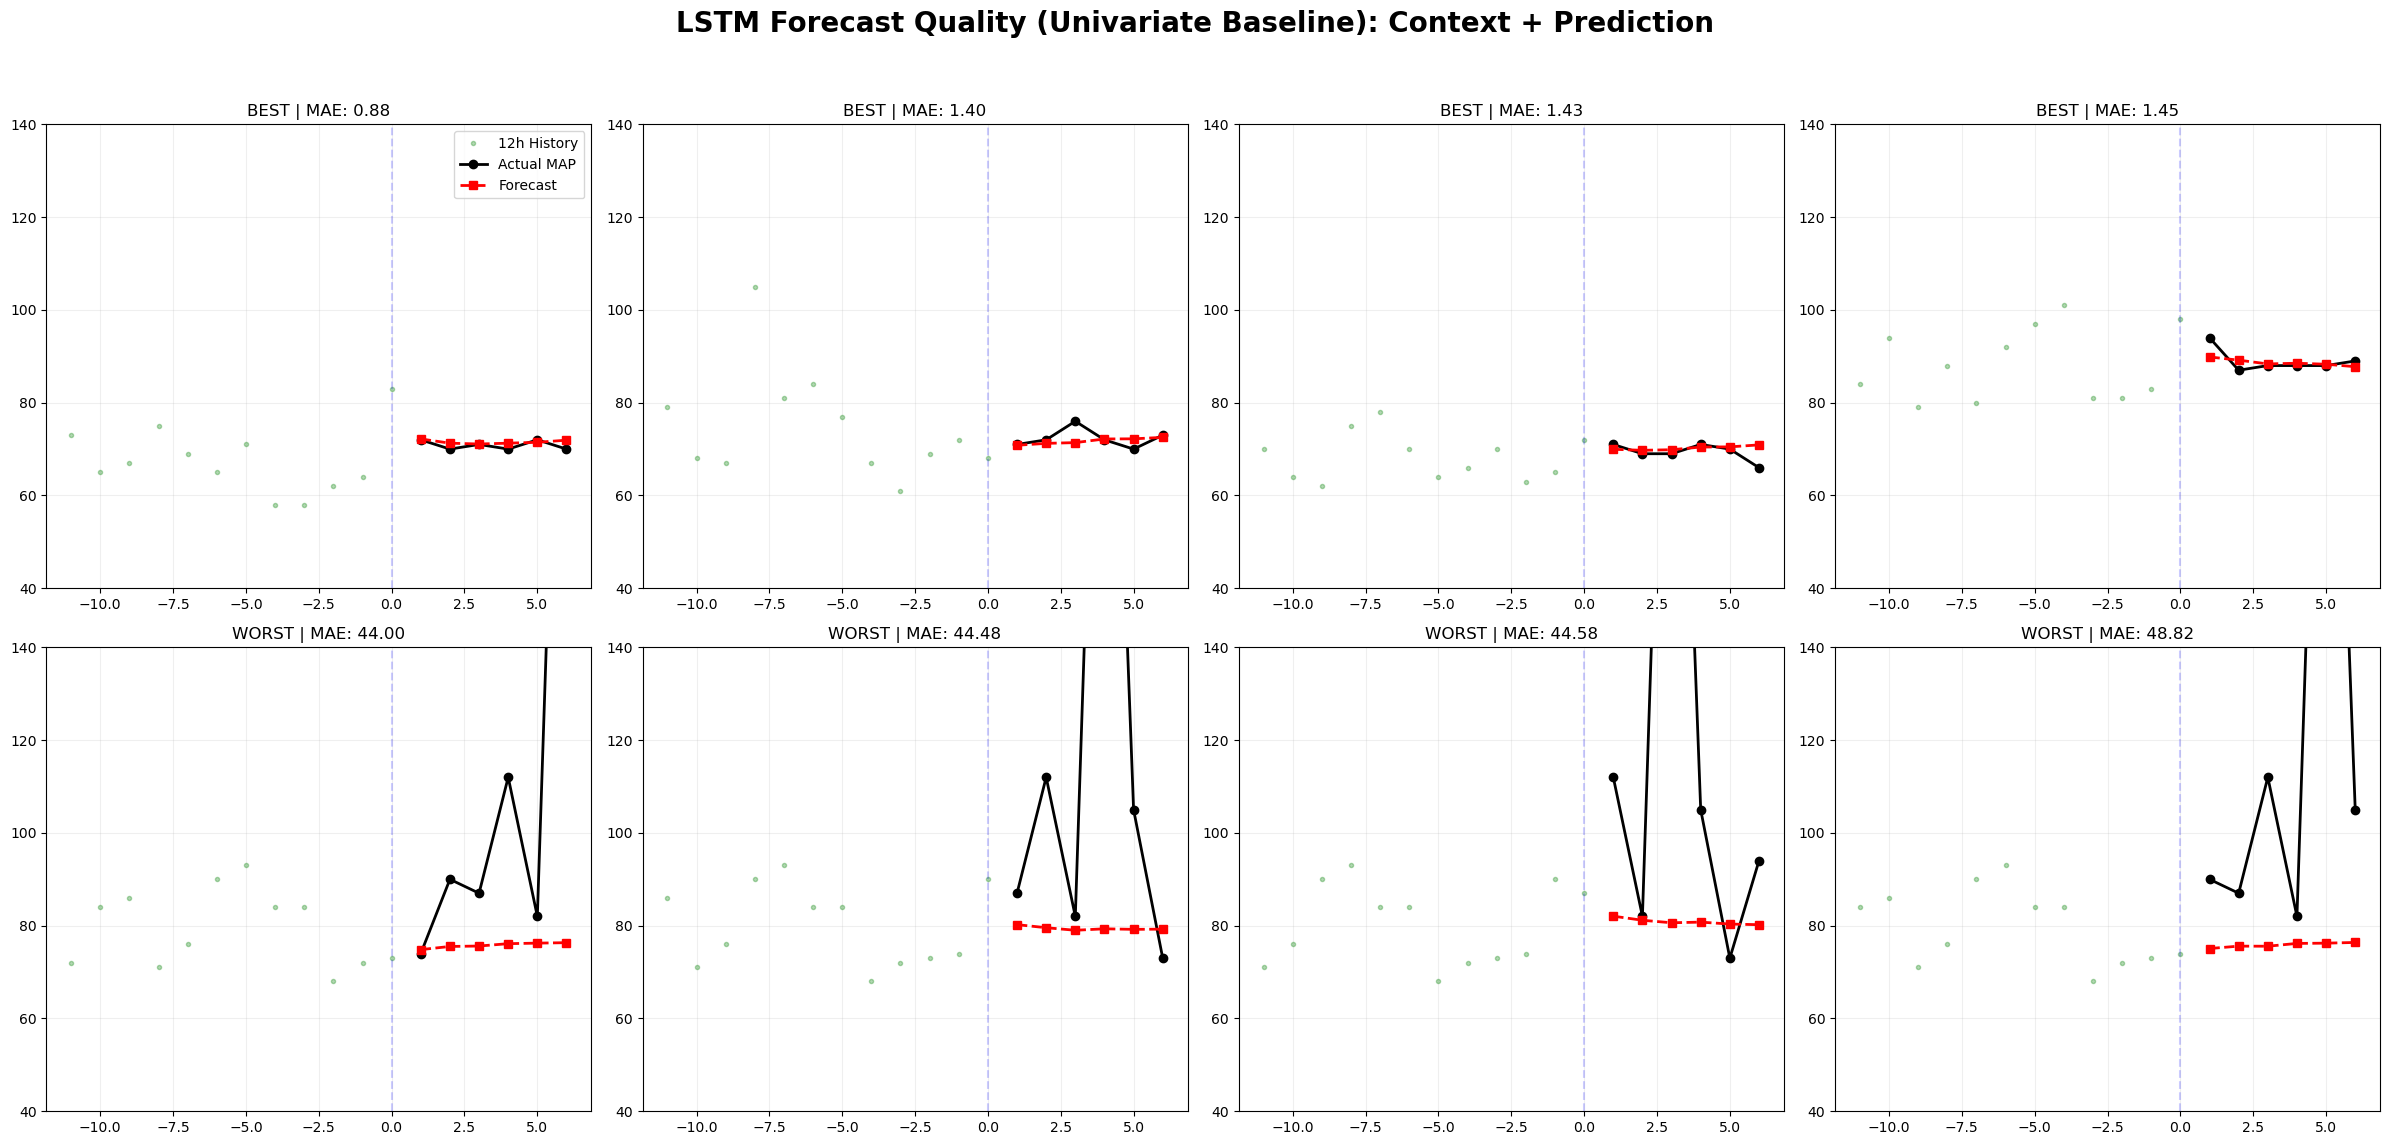

In [ ]:
uni_features = ['MAP']

# Prepare Data: Explicitly named "uni" variables
train_loader_uni, val_loader_uni, test_loader_uni, X_test_uni = prepare_lstm_data(
    df_train_scaled, 
    df_val_scaled, 
    df_test_scaled, 
    uni_features, 
    target_col='MAP'
)


In [ ]:
# 1. Optimize Univariate
study_uni = optuna.create_study(direction="minimize")
study_uni.optimize(create_objective(1, train_loader_uni, val_loader_uni), n_trials=50)

In [71]:
# 2. Retrain Best Univariate Model
final_uni_model = train_final_lstm(
    train_loader_uni, 
    val_loader_uni, 
    study_uni.best_params, 
    input_dim=1, 
    model_name='best_uni_lstm.pth'
)

In [ ]:
# 3. Evaluate Model
evaluation_uni = evaluate_lstm(final_uni_model, train_loader_uni, test_loader_uni, scaler_std)
preds_uni, actuals_uni = evaluation_uni['test_preds'], evaluation_uni['test_actuals']
# evaluation_uni

Horizon    | Train MAE  | Test MAE   | Gap       
---------------------------------------------
t+1 hour    | 6.96       | 7.50       | 0.54      
t+3 hour    | 7.69       | 8.22       | 0.53      
t+6 hour    | 8.11       | 8.68       | 0.57      


Results: t+1: 7.50 | t+3: 8.22 | t+6: 8.68


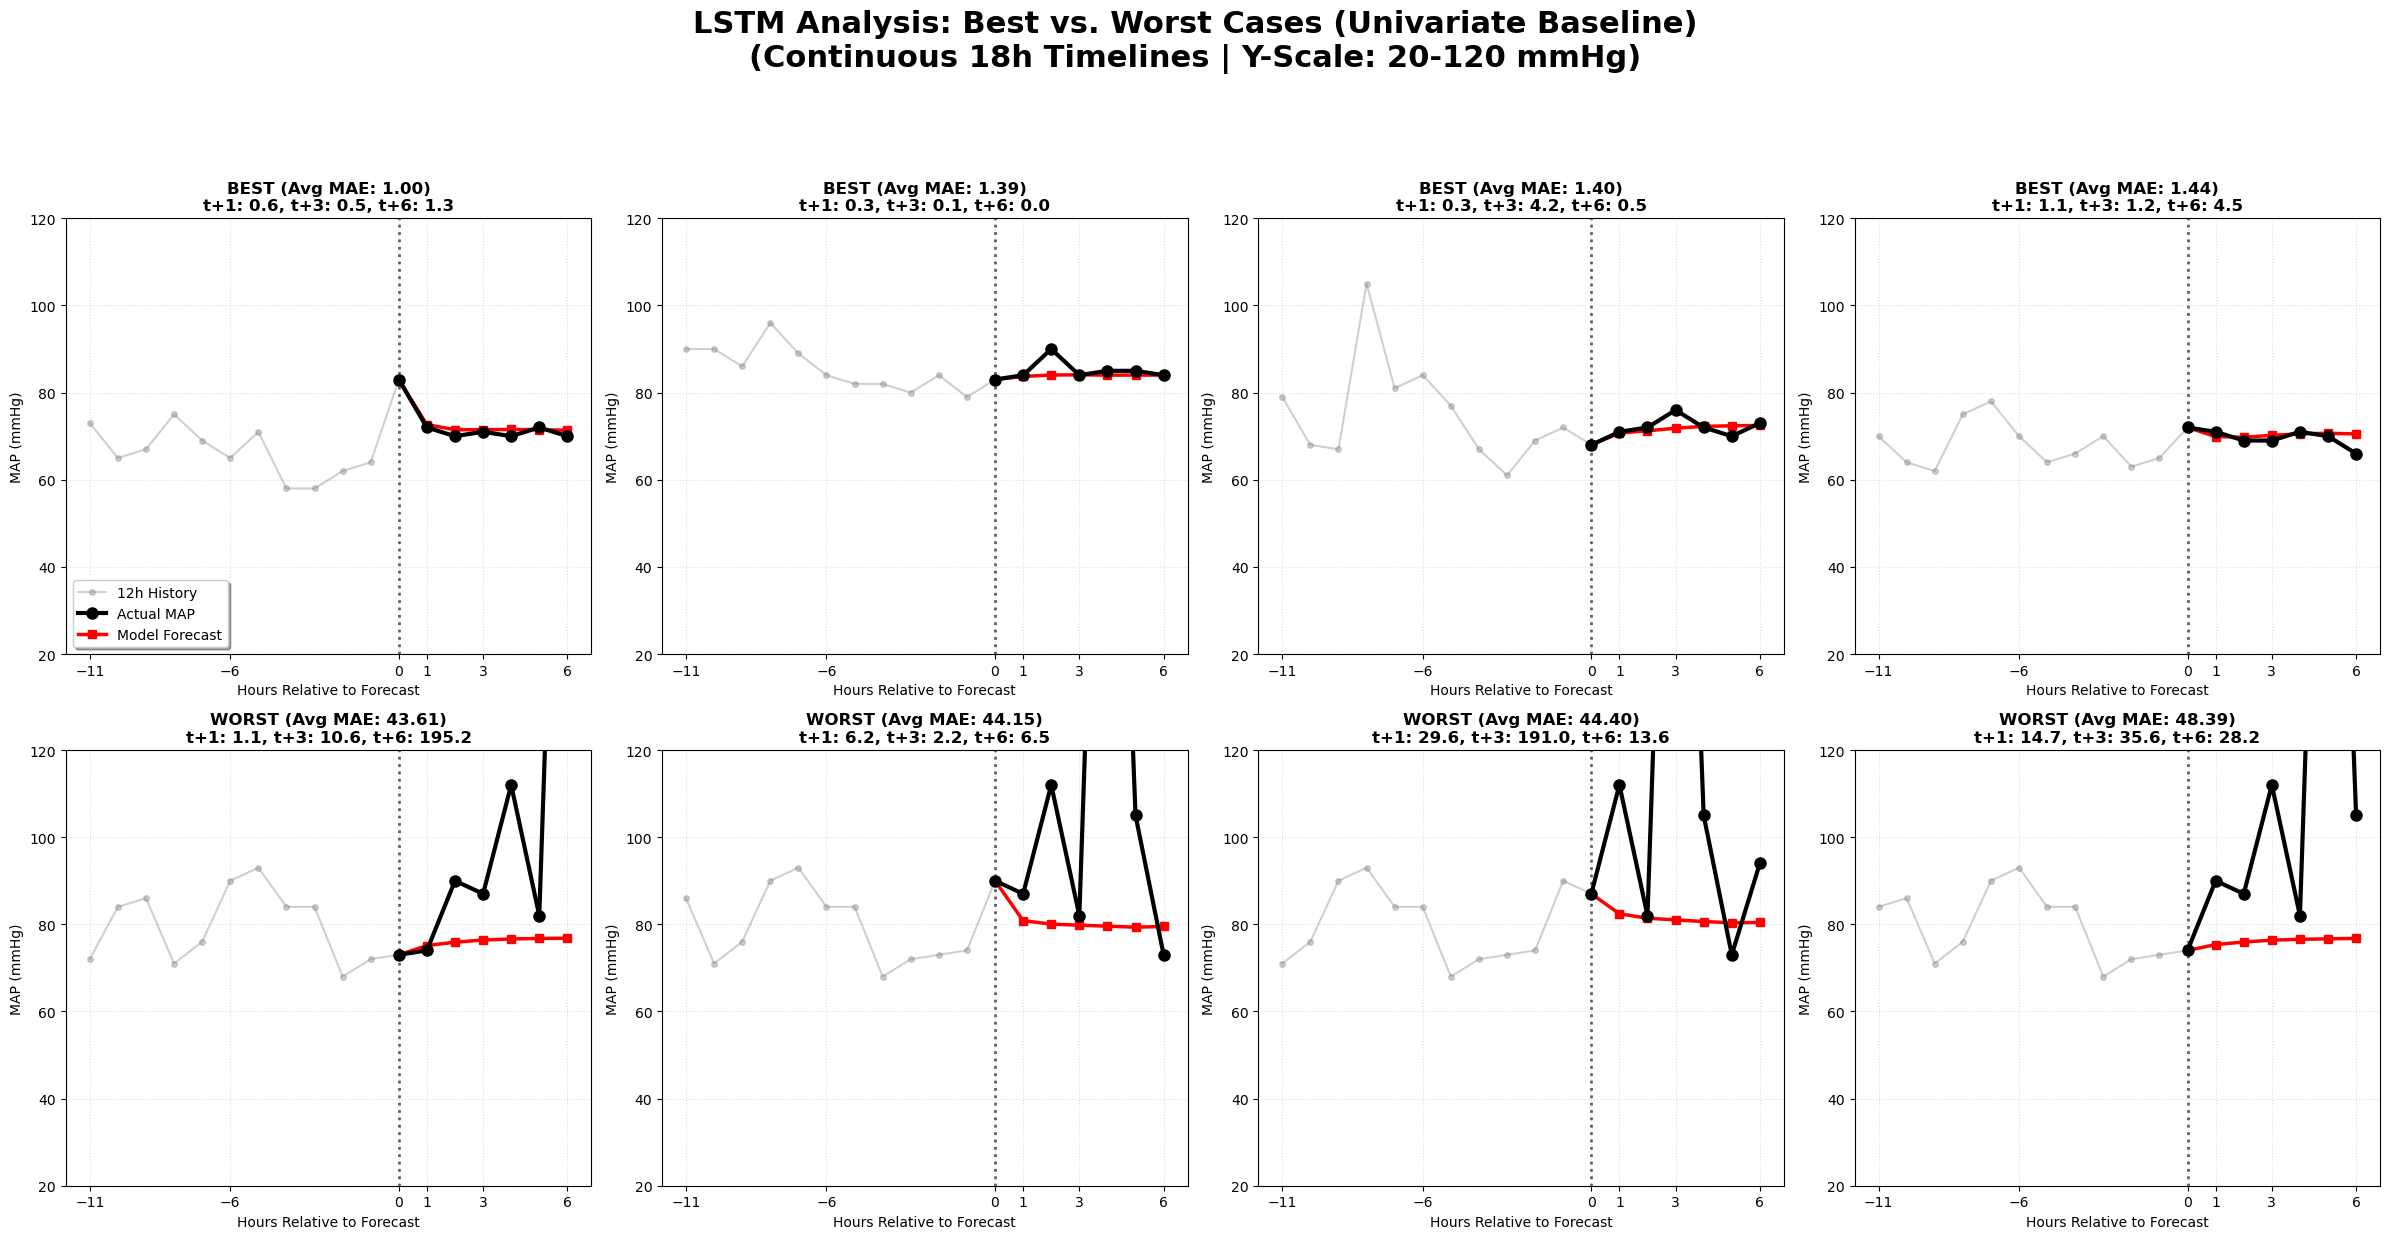

In [ ]:
# 3. Evaluate & Plot
preds_uni, actuals_uni = evaluate_lstm(final_uni_model, test_loader_uni, scaler_std)
# plot_lstm_results(X_test_uni, actuals_uni, preds_uni, scaler_std, title_suffix="(Univariate Baseline)")

### Multivariate Baseline LSTM

In [91]:
# --- MULTIVARIATE SETUP ---
multi_features = [
    'MAP', 'Heart Rate', 'Respiratory Rate', 'Temperature Fahrenheit', 
    'age', 'PEEP set', 'Norepinephrine', 'NaCl 0.9%', 
    'GCS - Motor Response', 'gender_female'
]

# Prepare Data: Explicitly named "multi" variables
train_loader_multi, val_loader_multi, test_loader_multi, X_test_multi = prepare_lstm_data(
    df_train_scaled, 
    df_val_scaled, 
    df_test_scaled, 
    multi_features, 
    target_col='MAP'
)

In [92]:
# 1. Optimize Multivariate
study_multi_full = optuna.create_study(direction="minimize")
study_multi_full.optimize(create_objective(10, train_loader_multi, val_loader_multi), n_trials=50)

[I 2026-03-14 22:56:25,361] A new study created in memory with name: no-name-b45cda56-f83c-44d5-abe7-8593cc683cfa
[I 2026-03-14 22:57:11,163] Trial 0 finished with value: 0.576760323680177 and parameters: {'hidden_dim': 16, 'num_layers': 5, 'lr': 0.00010113070519242763, 'dropout': 0.40043848141295335}. Best is trial 0 with value: 0.576760323680177.
[I 2026-03-14 22:58:03,275] Trial 1 finished with value: 0.5403763437453581 and parameters: {'hidden_dim': 32, 'num_layers': 5, 'lr': 0.00031646251979598224, 'dropout': 0.15752245795404218}. Best is trial 1 with value: 0.5403763437453581.
[I 2026-03-14 22:59:11,982] Trial 2 finished with value: 0.646364835604113 and parameters: {'hidden_dim': 64, 'num_layers': 5, 'lr': 0.00287630775797802, 'dropout': 0.17424340340947966}. Best is trial 1 with value: 0.5403763437453581.
[I 2026-03-14 22:59:49,425] Trial 3 finished with value: 0.6374547654876903 and parameters: {'hidden_dim': 48, 'num_layers': 3, 'lr': 0.003564194343400916, 'dropout': 0.286568

In [93]:
# 2. Retrain Best Multivariate Model
multi_model_full = train_final_lstm(
    train_loader_multi, 
    val_loader_multi, 
    study_multi_full.best_params, 
    input_dim=10, 
    model_name='best_multi_lstm.pth'
)

In [94]:
# 3. Evaluate Model
evaluation_multi_full = evaluate_lstm(multi_model_full, train_loader_multi, test_loader_multi, scaler_std)
preds_multi_full, actuals_multi_full = evaluation_multi_full['test_preds'], evaluation_multi_full['test_actuals']

Horizon    | Train MAE  | Test MAE   | Gap       
---------------------------------------------
t+1 hour    | 6.92       | 7.63       | 0.71      
t+3 hour    | 7.41       | 8.18       | 0.77      
t+6 hour    | 7.77       | 8.63       | 0.86      


In [ ]:
# # 3. Evaluate & Plot
# preds_multi_full, actuals_multi_full = evaluate_lstm(multi_model_full, test_loader_multi, scaler_std)

### Leaner Multi Features
It has been hypothethised that there is currently way too much feature for the data, so I decided to cut down to much less more significant features instead which was shown in the cross correlation plot in the main report to be the most highly correlated.

In [96]:
# --- MULTIVARIATE SETUP ---
lean_multi_features = [
    'MAP', 'Heart Rate', 'PEEP set', 'Norepinephrine', 
    'GCS - Motor Response'
]

# Prepare Data: Explicitly named "multi" variables
train_loader_multi, val_loader_multi, test_loader_multi, X_test_multi = prepare_lstm_data(
    df_train_scaled, 
    df_val_scaled, 
    df_test_scaled, 
    lean_multi_features, 
    target_col='MAP'
)

In [36]:
# 1. Optimize Multivariate
study_multi = optuna.create_study(direction="minimize")
study_multi.optimize(create_objective(5, train_loader_multi, val_loader_multi), n_trials=50)

[I 2026-03-12 21:43:42,920] A new study created in memory with name: no-name-fea944de-952c-487d-ad05-d62a171c603a
[I 2026-03-12 21:44:32,690] Trial 0 finished with value: 0.5341108999386126 and parameters: {'hidden_dim': 96, 'num_layers': 3, 'lr': 0.00010380131418707099, 'dropout': 0.12832441364334715}. Best is trial 0 with value: 0.5341108999386126.
[I 2026-03-12 21:45:49,120] Trial 1 finished with value: 0.5679089778235981 and parameters: {'hidden_dim': 80, 'num_layers': 5, 'lr': 0.009625673884319397, 'dropout': 0.30729328311766346}. Best is trial 0 with value: 0.5341108999386126.
[I 2026-03-12 21:46:20,730] Trial 2 finished with value: 0.5362419150009448 and parameters: {'hidden_dim': 80, 'num_layers': 2, 'lr': 0.0004152126821303048, 'dropout': 0.3825132818827824}. Best is trial 0 with value: 0.5341108999386126.
[I 2026-03-12 21:47:13,661] Trial 3 finished with value: 0.5631126556165365 and parameters: {'hidden_dim': 32, 'num_layers': 5, 'lr': 0.0016155874685522711, 'dropout': 0.118

In [97]:
# 2. Retrain Best Multivariate Model
final_multi_model = train_final_lstm(
    train_loader_multi, 
    val_loader_multi, 
    study_multi.best_params, 
    input_dim=5, 
    model_name='best_multi_lstm.pth'
)

In [98]:
# 3. Evaluate Model
evaluation_multi = evaluate_lstm(final_multi_model, train_loader_multi, test_loader_multi, scaler_std)
preds_multi, actuals_multi = evaluation_multi['test_preds'], evaluation_multi['test_actuals']

Horizon    | Train MAE  | Test MAE   | Gap       
---------------------------------------------
t+1 hour    | 6.76       | 7.51       | 0.74      
t+3 hour    | 7.45       | 8.38       | 0.92      
t+6 hour    | 7.77       | 8.79       | 1.01      


In [40]:
# Assuming your model is named 'final_model'
total_params = sum(p.numel() for p in final_model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 879,846


In [ ]:
def get_stay_ids_for_test_set(df, window_size=18):
    """
    Extracts stay_ids for every valid window in the test set.
    """
    stay_ids = []
    # We group by stay_id to match the prepare_lstm_data logic
    for sid, group in df.groupby('stay_id'):
        if len(group) >= window_size:
            # For a group of length N, there are (N - window_size + 1) windows
            # All of these windows belong to this specific sid
            num_windows = len(group) - window_size + 1
            stay_ids.extend([sid] * num_windows)
            
    return np.array(stay_ids)

# Generate the ID list for your multivariate test set
test_stay_ids = get_stay_ids_for_test_set(df_test_scaled)

print(f"Total Windows: {len(X_test_multi)}")

Total Windows: 2315
Total IDs extracted: 2315


### Visualisation

In [101]:
# Create the results packages for your plotting function
uni_results = {
    'preds': preds_uni,         # The output from evaluate_lstm (unscaled mmHg)
    'actuals': actuals_uni, 
    'ids': test_stay_ids    # Generated using the same function above
}

multi_results = {
    'preds': preds_multi_full,       # Your 'preds_multi' from Step 3
    'actuals': actuals_multi_full, 
    'ids': test_stay_ids
}

In [104]:
def plot_lstm_comparison(target_ids, lstm_uni_pkg, lstm_multi_pkg, df_test, scaler_std):
    """
    Plots the final 18h window for 8 patients, comparing:
    LSTM Univariate vs. LSTM Leaner Multivariate.
    Numbered IDs and Dual MAE metrics added.
    """
    fig, axes = plt.subplots(2, 4, figsize=(24, 13))
    fig.suptitle("LSTM: Continuous 18h Patient Timelines\n(12 Hours History, 6 Hours Forecast)", 
                 fontsize=22, fontweight='bold', y=0.98)

    for i, sid in enumerate(target_ids):
        ax = axes[i // 4, i % 4]
        
        # 1. Fetch History from the main test dataframe (df_test)
        patient_full_history = df_test[df_test['stay_id'] == sid].sort_values('charttime')
        history_vals = patient_full_history.iloc[-18:-6]['MAP'].values
        history_hours = np.arange(-11, 1) # -11 to 0
        last_hist_val = history_vals[-1]
        
        # 2. Extract Forecasts (Hours 1 to 6)
        forecast_hours = np.arange(1, 7)
        full_x = np.insert(forecast_hours, 0, 0) # X-axis for stitching

        # A. Actuals (Ground Truth)
        actual_vals = patient_full_history.iloc[-6:]['MAP'].values
        stitch_actual = np.insert(actual_vals, 0, last_hist_val)

        # B. LSTM Univariate
        idx_uni = np.where(lstm_uni_pkg['ids'] == sid)[0][-1]
        pred_uni_vals = lstm_uni_pkg['preds'][idx_uni]
        stitch_uni = np.insert(pred_uni_vals, 0, last_hist_val)

        # C. LSTM Leaner Multivariate
        idx_lean = np.where(lstm_multi_pkg['ids'] == sid)[0][-1]
        pred_lean_vals = lstm_multi_pkg['preds'][idx_lean]
        stitch_lean = np.insert(pred_lean_vals, 0, last_hist_val)

        # --- 3. METRICS CALCULATION ---
        # Univariate MAE
        u_mae1, u_mae3, u_mae6 = [np.abs(actual_vals[j] - pred_uni_vals[j]) for j in [0, 2, 5]]
        # Multivariate (Leaner) MAE
        m_mae1, m_mae3, m_mae6 = [np.abs(actual_vals[j] - pred_lean_vals[j]) for j in [0, 2, 5]]

        # --- 4. PLOTTING ---
        # A. History (Gray)
        ax.plot(history_hours, history_vals, color='#7f8c8d', linestyle='-', marker='o', 
                markersize=4, alpha=0.4, label="12h History")
        
        # B. Ground Truth (Black)
        ax.plot(full_x, stitch_actual, 'k-o', label="Actual MAP", linewidth=3, markersize=8, zorder=5)
        
        # C. Model Predictions (Uni = Blue Dashed, Leaner Multi = Red Solid)
        ax.plot(full_x, stitch_uni, 'b--', label="Univariate LSTM", alpha=0.7, linewidth=2)
        ax.plot(full_x, stitch_lean, 'r-s', label="Multi LSTM", linewidth=2.5)

        # --- 5. FORMATTING & TITLE ---
        ax.axvline(0, color='#2c3e50', linestyle=':', linewidth=2, alpha=0.8)
        ax.set_ylim(20, 120)
        
        title_str = (f"({i+1}) Stay ID: {sid}\n"
                     f"Uni MAE -> t+1: {u_mae1:.1f}, t+3: {u_mae3:.1f}, t+6: {u_mae6:.1f}\n"
                     f"Multi MAE -> t+1: {m_mae1:.1f}, t+3: {m_mae3:.1f}, t+6: {m_mae6:.1f}")
        
        ax.set_title(title_str, fontsize=11, fontweight='semibold')
        
        ax.set_xticks([-11, -6, 0, 1, 3, 6])
        ax.set_xlabel("Hours Relative to Forecast", fontsize=10)
        ax.set_ylabel("MAP (mmHg)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        if i == 0:
            ax.legend(loc='lower left', fontsize=10, frameon=True, shadow=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()

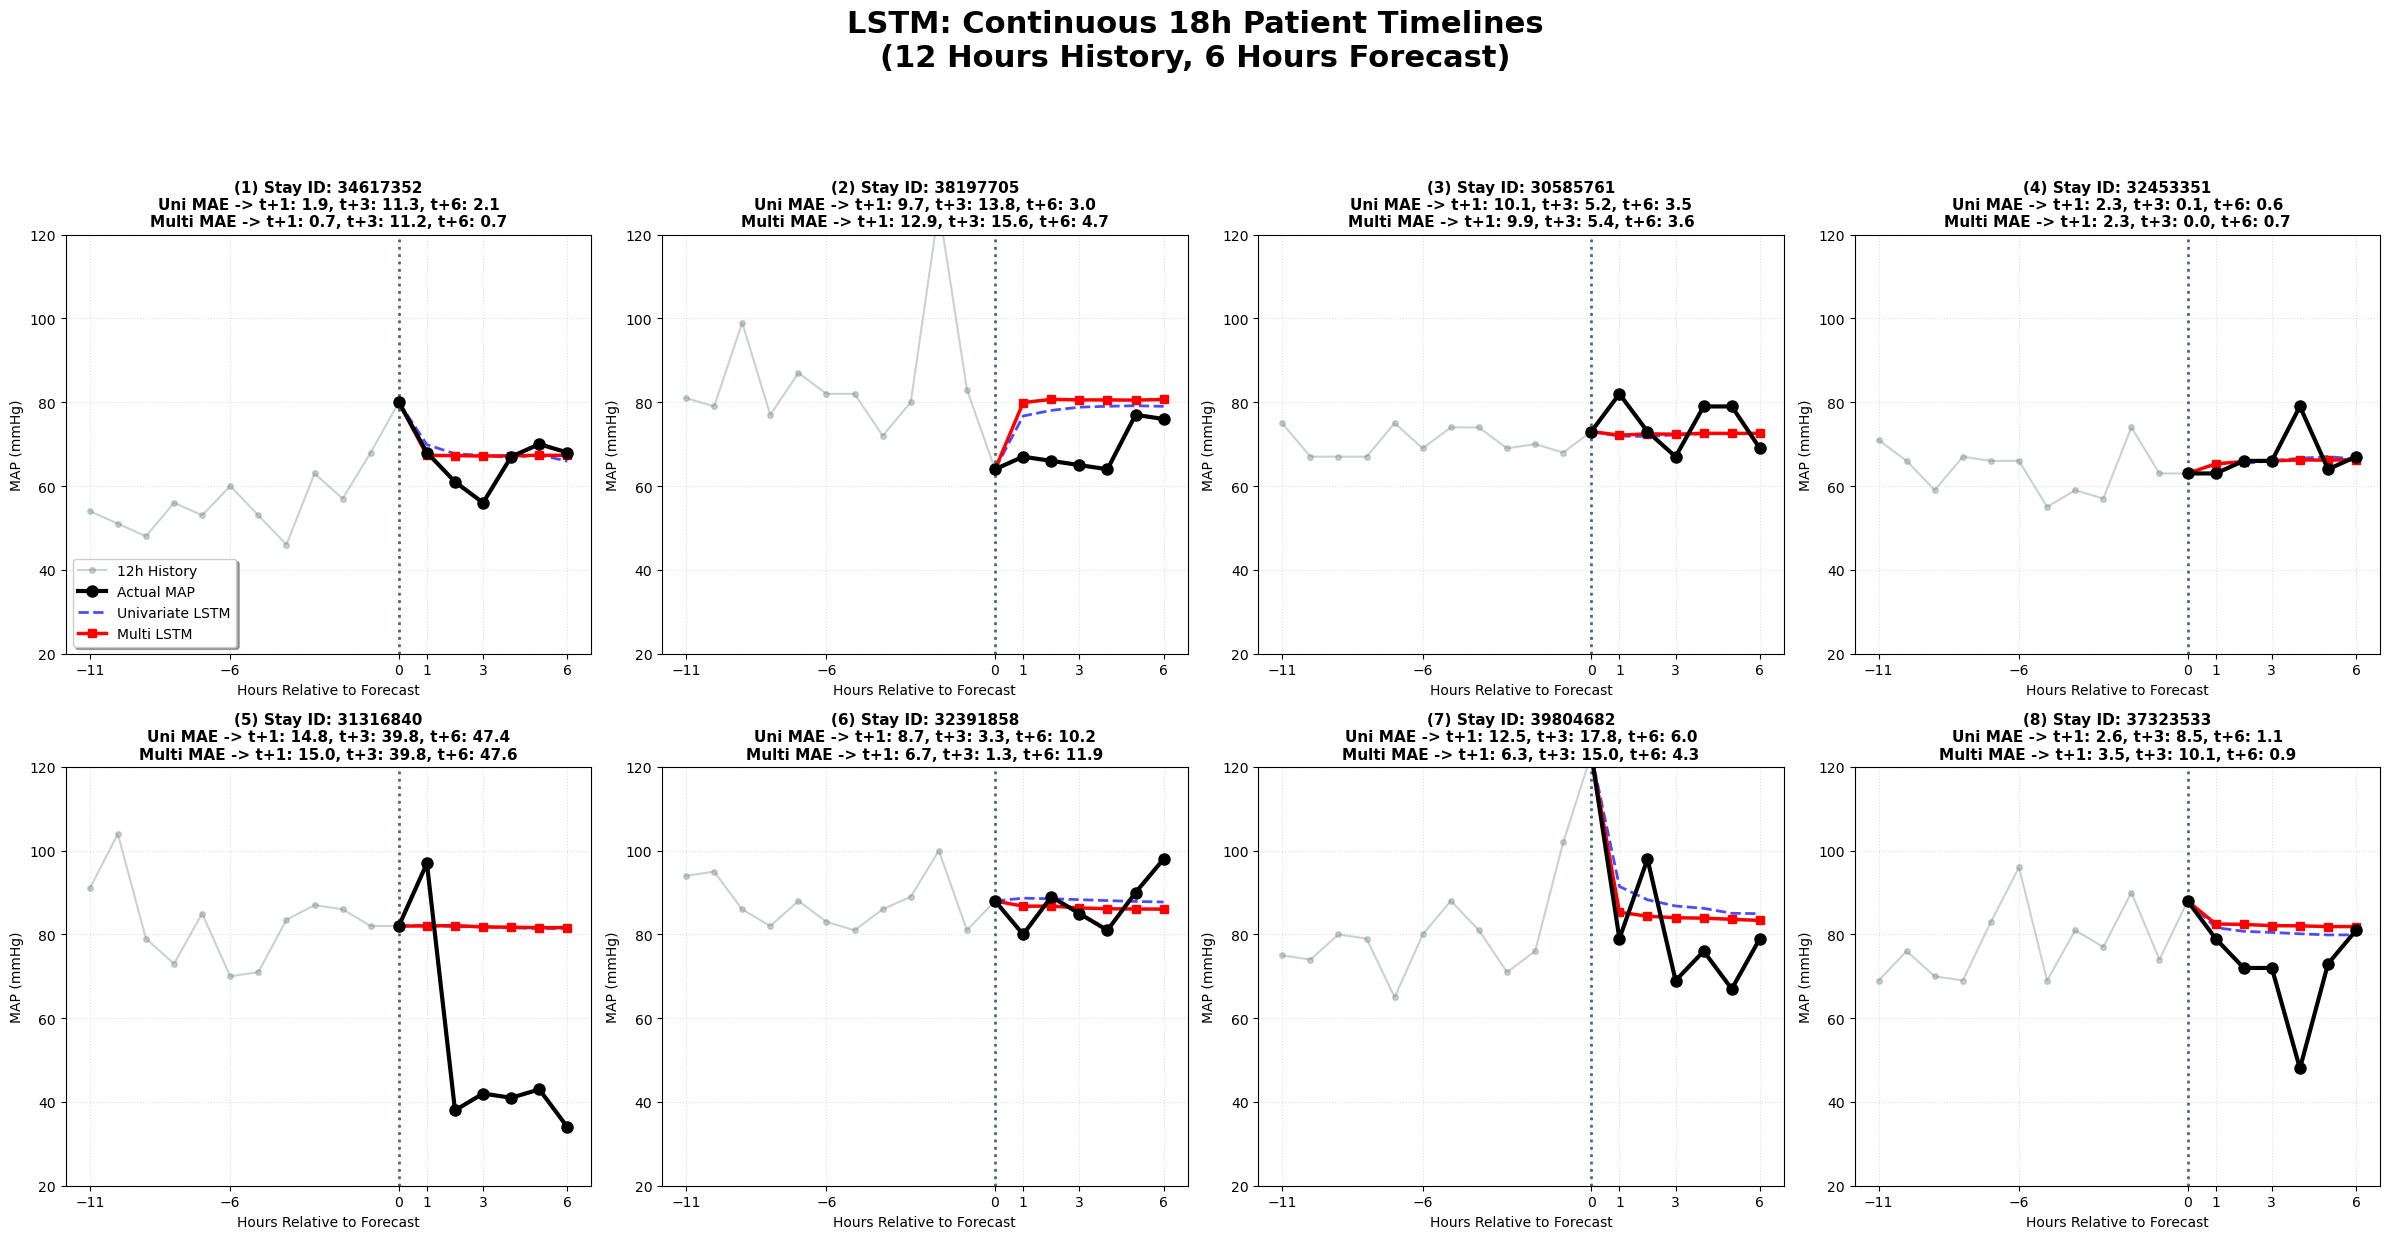

In [105]:
target_stay_ids = [34617352, 38197705, 30585761, 32453351, 31316840, 32391858, 39804682, 37323533]

plot_lstm_comparison(
    target_ids=target_stay_ids,
    lstm_uni_pkg=uni_results,
    lstm_multi_pkg=multi_results,
    df_test=df_test,
    scaler_std=scaler_std
)

In [106]:
lstm_data = []
for sid in target_stay_ids:
    idx = np.where(multi_results['ids'] == sid)[0][-1]
    lstm_data.append({'stay_id': sid, 'preds': multi_results['preds'][idx]})
lstm_visual_df = pd.DataFrame(lstm_data)
lstm_visual_df

,stay_id,preds
0,34617352,"[67.33450832897958, 67.24881575164586, 67.1653..."
1,38197705,"[79.90508318394606, 80.7044349431457, 80.55346..."
2,30585761,"[72.1414116869522, 72.44723316180644, 72.36127..."
3,32453351,"[65.29334650637787, 65.84881148798503, 66.0025..."
4,31316840,"[82.02889989526727, 82.11834140521502, 81.8039..."
5,32391858,"[86.74716172472863, 86.77046919508425, 86.3354..."
6,39804682,"[85.31640411307328, 84.35171434179568, 83.9909..."
7,37323533,"[82.51623783030868, 82.38329077528343, 82.1086..."


In [107]:
lstm_visual_df.to_csv('lstm_visual_multi.csv', index=False)

### Appendix
* Unused report plots only for just looking at best and worst results

In [ ]:
def plot_lstm_results(X_test, actuals_mmhg, preds_mmhg, scaler_std, title_suffix=""):
    """
    Plots best and worst cases for a single LSTM model.
    Styling is matched to the Chronos-2 and Master Comparison plots.
    """
    # Calculate MAE for sorting
    window_maes = np.mean(np.abs(preds_mmhg - actuals_mmhg), axis=1)
    sorted_idx = np.argsort(window_maes)
    plot_indices = np.concatenate([sorted_idx[:4], sorted_idx[-4:]])

    fig, axes = plt.subplots(2, 4, figsize=(24, 13))
    fig.suptitle(f"LSTM Analysis: Best vs. Worst Cases {title_suffix}\n(Continuous 18h Timelines | Y-Scale: 20-120 mmHg)", 
                 fontsize=22, fontweight='bold', y=0.98)

    map_std, map_mean = scaler_std.scale_[0], scaler_std.mean_[0]

    for i, idx in enumerate(plot_indices):
        ax = axes[i // 4, i % 4]
        
        # 1. Prepare Data
        # Unscale history (Column 0 is always MAP)
        history_vals = (X_test[idx][:, 0] * map_std) + map_mean
        history_hours = np.arange(-11, 1)
        last_hist_val = history_vals[-1]
        
        actual_vals = actuals_mmhg[idx]
        forecast_vals = preds_mmhg[idx]
        forecast_hours = np.arange(1, 7)
        
        # 2. Stitching Logic (Connecting Hour 0 to Hour 1)
        full_x = np.insert(forecast_hours, 0, 0)
        stitch_actual = np.insert(actual_vals, 0, last_hist_val)
        stitch_forecast = np.insert(forecast_vals, 0, last_hist_val)
        
        # 3. Plotting
        # History (Gray - Chronos Style)
        ax.plot(history_hours, history_vals, color='#7f8c8d', linestyle='-', marker='o', 
                markersize=4, alpha=0.4, label="12h History")
        
        # Ground Truth (Solid Black)
        ax.plot(full_x, stitch_actual, 'k-o', label="Actual MAP", linewidth=3, markersize=8, zorder=5)
        
        # Forecast (Red Solid with Squares - Chronos 'Multi' style)
        ax.plot(full_x, stitch_forecast, 'r-s', label="Model Forecast", linewidth=2.5)
        
        # 4. Formatting
        ax.axvline(0, color='#2c3e50', linestyle=':', linewidth=2, alpha=0.8)
        ax.set_ylim(20, 120)
        
        # Calculate point metrics for the title
        mae_1 = np.abs(actual_vals[0] - forecast_vals[0])
        mae_3 = np.abs(actual_vals[2] - forecast_vals[2])
        mae_6 = np.abs(actual_vals[5] - forecast_vals[5])
        
        status = "BEST" if i < 4 else "WORST"
        ax.set_title(f"{status} (Avg MAE: {window_maes[idx]:.2f})\nt+1: {mae_1:.1f}, t+3: {mae_3:.1f}, t+6: {mae_6:.1f}", 
                     fontsize=12, fontweight='semibold')
        
        ax.set_xticks([-11, -6, 0, 1, 3, 6])
        ax.set_xlabel("Hours Relative to Forecast", fontsize=10)
        ax.set_ylabel("MAP (mmHg)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        if i == 0:
            ax.legend(loc='lower left', fontsize=10, frameon=True, shadow=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()


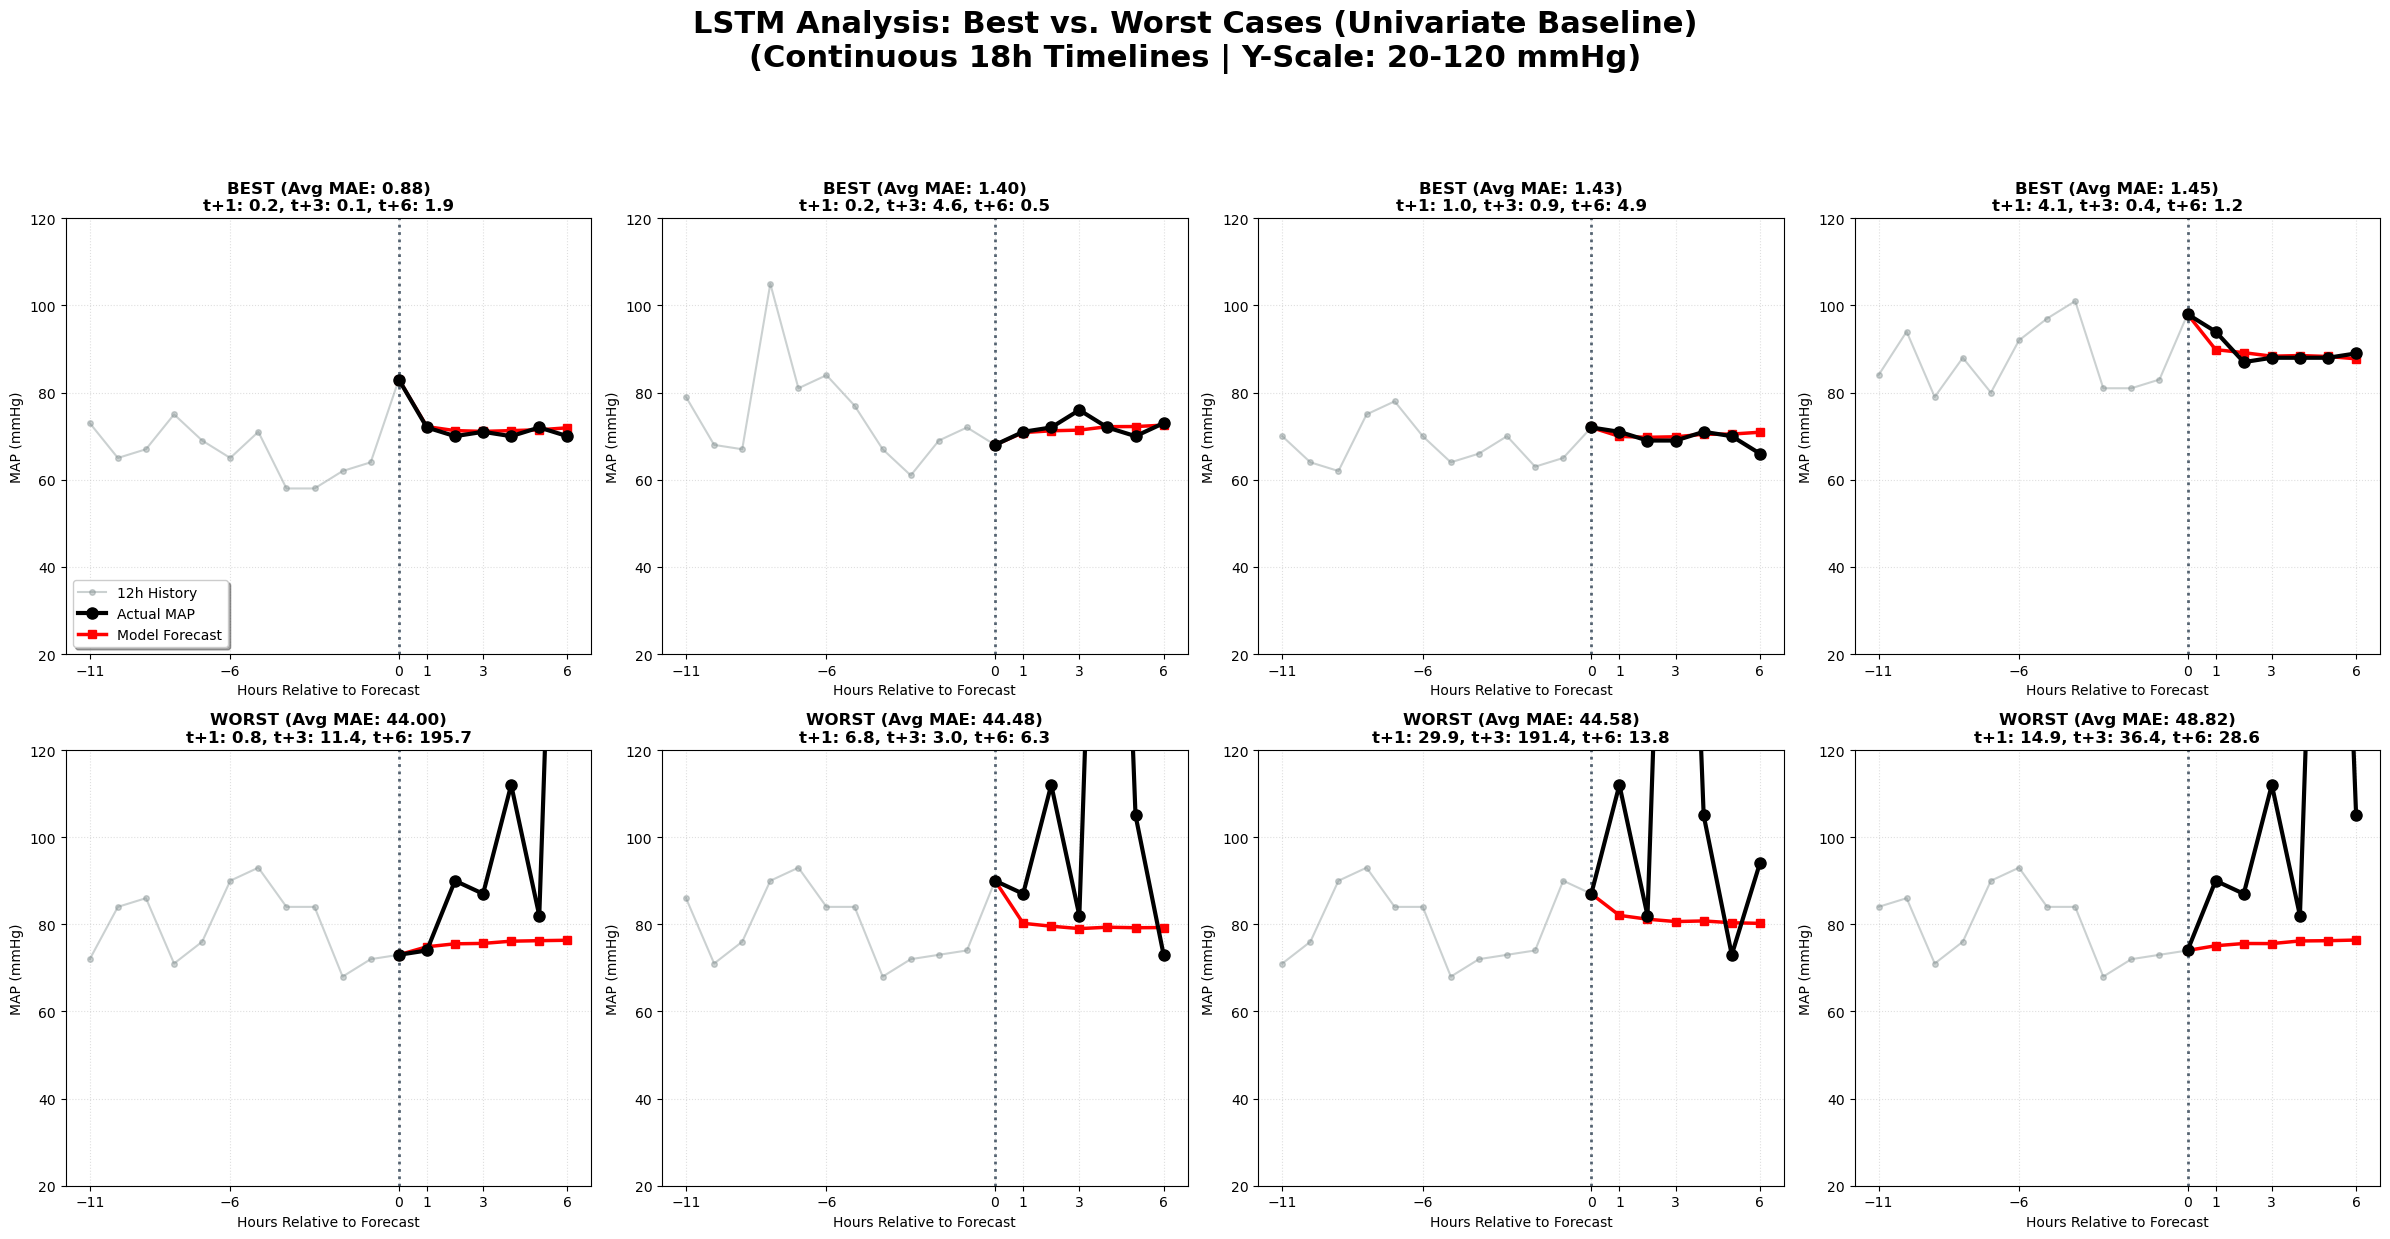

In [67]:
# Best and Worst Case for Univariate
plot_lstm_results(X_test_uni, actuals_uni, preds_uni, scaler_std, title_suffix="(Univariate Baseline)")

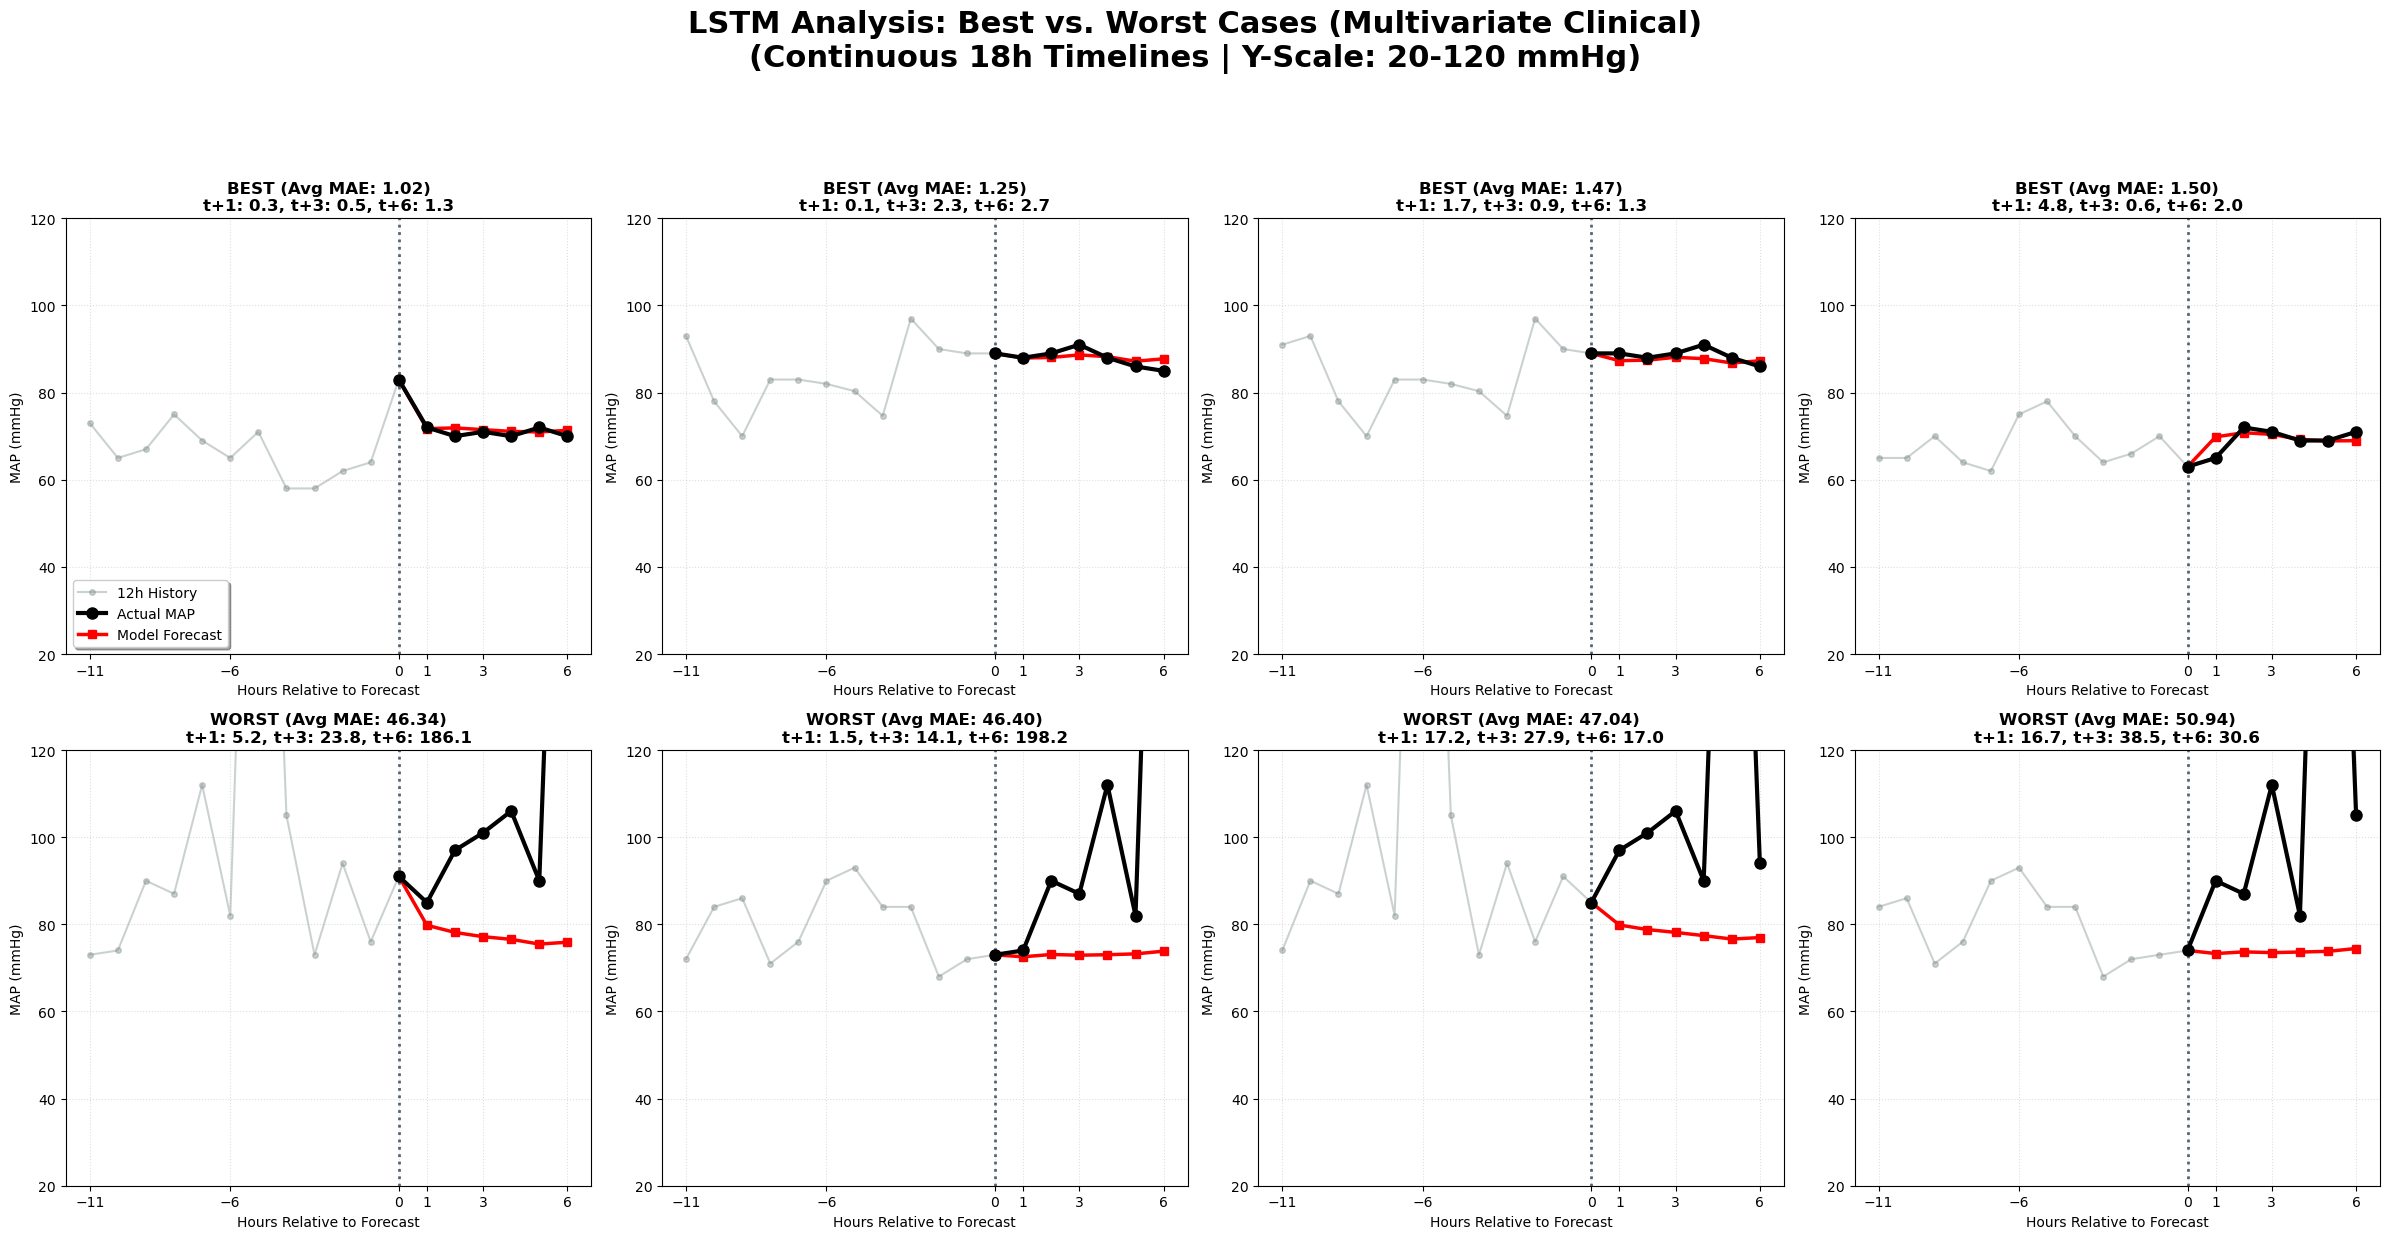

In [70]:
# Best and Worst Case for Multivariate
plot_lstm_results(X_test_multi, actuals_multi, preds_multi, scaler_std, title_suffix="(Multivariate Clinical)")